# t-SNE: Offline Dataset vs Trained Policy Rollouts

Compares the (next_state, action) distribution of the sparse D4RL offline dataset against
trajectories collected by rolling out a trained GORMPO policy in the real environment.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pickle
import numpy as np
import torch
import gym
import d4rl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from models.policy_models import MLP, ActorProb, Critic, DiagGaussian
from algo.sac import SACPolicy

import warnings
warnings.filterwarnings('ignore')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
These new versions include large bug fixes, new versions of Python, and are where all new development will continue. Please upgrade these libraries as soon as you're able to do so.
If you'd like to read more about the story behind this switch, please check out ]8;;https://farama.org/Announcing-Minari\this blog post]8;;\.
No module named 'flow'
/home/ubuntu/miniconda3/envs/gormpo/lib/python3.8/site-packages/glfw/__init__.py:917: GLFWError: (65550) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)
No module named 'carla'
pybullet build time: Jan 29 2025 23:19:57


## Configuration

In [2]:
# ── Task ──────────────────────────────────────────────────────────────────────
TASK        = 'halfcheetah-medium-expert-v2'
SPARSITY    = '72.5'   # '72.5' | '57.5' | '78' | None (for non-sparse)

# Sparse dataset path  (set to None to fall back to d4rl.qlearning_dataset)
DATASET_PATH = f'/public/d4rl/sparse_datasets/halfcheetah_medium_expert_sparse_{SPARSITY}.pkl'

# ── Policy checkpoint ─────────────────────────────────────────────────────────
DENSITY_MODEL = 'vae'    # 'kde' | 'realnvp' | 'vae' | 'neuralODE' | 'diffusion'
POLICY_PATH = (
    '/public/gormpo/models/rl/halfcheetah-medium-expert-v2/kde/'
    'seed_456_0224_005407_halfcheetah_medium_expert_v2_mbpo_sparse_72/'
    'policy_halfcheetah-medium-expert-v2.pth'
)

# ── Rollout settings ──────────────────────────────────────────────────────────
N_ROLLOUT_EPISODES = 100   # number of episodes to collect from the policy
DETERMINISTIC      = True  # use deterministic (mode) actions

# ── t-SNE / subsampling ───────────────────────────────────────────────────────
MAX_OFFLINE_SAMPLES = 10_000   # cap for dataset points (for speed)
TSNE_PERPLEXITY     = 40
TSNE_N_ITER         = 1000
RANDOM_SEED         = 42

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [ ]:
seed_456_0224_005407_halfcheetah_medium_expert_v2_mbpo_sparse_72.5

## Load sparse offline dataset

In [3]:
if DATASET_PATH is not None and os.path.exists(DATASET_PATH):
    with open(DATASET_PATH, 'rb') as f:
        dataset = pickle.load(f)
    print(f'Loaded sparse dataset from {DATASET_PATH}')
else:
    env_tmp = gym.make(TASK)
    dataset = d4rl.qlearning_dataset(env_tmp)
    env_tmp.close()
    print(f'Loaded d4rl dataset for {TASK}')

offline_next_obs = dataset['next_observations']   # (N, obs_dim)
offline_actions  = dataset['actions']              # (N, act_dim)
print(f'Dataset size      : {offline_next_obs.shape[0]:,}')
print(f'Observation shape : {offline_next_obs.shape[1:]}')
print(f'Action shape      : {offline_actions.shape[1:]}')

Loaded sparse dataset from /public/d4rl/sparse_datasets/halfcheetah_medium_expert_sparse_72.5.pkl
Dataset size      : 1,450,000
Observation shape : (17,)
Action shape      : (6,)


## Load trained policy

In [4]:
def load_policy(policy_path, obs_dim, action_dim, action_space, device='cpu'):
    """Reconstruct and load a saved SACPolicy."""
    actor_backbone   = MLP(input_dim=obs_dim,               hidden_dims=[256, 256])
    critic1_backbone = MLP(input_dim=obs_dim + action_dim,  hidden_dims=[256, 256])
    critic2_backbone = MLP(input_dim=obs_dim + action_dim,  hidden_dims=[256, 256])

    dist = DiagGaussian(
        latent_dim=actor_backbone.output_dim,
        output_dim=action_dim,
        unbounded=True,
        conditioned_sigma=True,
    )
    actor   = ActorProb(actor_backbone, dist, device)
    critic1 = Critic(critic1_backbone, device)
    critic2 = Critic(critic2_backbone, device)

    actor_optim   = torch.optim.Adam(actor.parameters(),   lr=3e-4)
    critic1_optim = torch.optim.Adam(critic1.parameters(), lr=3e-4)
    critic2_optim = torch.optim.Adam(critic2.parameters(), lr=3e-4)

    policy = SACPolicy(
        actor, critic1, critic2,
        actor_optim, critic1_optim, critic2_optim,
        action_space=action_space,
        dist=dist,
        device=device,
    )
    state_dict = torch.load(policy_path, map_location=device)
    policy.load_state_dict(state_dict)
    policy.eval()
    print(f'Policy loaded from {policy_path}')
    return policy


env = gym.make(TASK)
obs_dim    = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

policy = load_policy(
    POLICY_PATH,
    obs_dim=obs_dim,
    action_dim=action_dim,
    action_space=env.action_space,
    device=DEVICE,
)
print(f'obs_dim={obs_dim}, action_dim={action_dim}')

Policy loaded from /public/gormpo/models/rl/halfcheetah-medium-expert-v2/kde/seed_456_0224_005407_halfcheetah_medium_expert_v2_mbpo_sparse_72.5/policy_halfcheetah-medium-expert-v2.pth
obs_dim=17, action_dim=6


## Rollout policy in real environment

In [5]:
def collect_rollouts(policy, env, n_episodes, deterministic=True):
    """Roll out policy for n_episodes and return (next_obs, action) arrays."""
    all_next_obs = []
    all_actions  = []
    ep_returns   = []
    ep_lengths   = []

    for ep in range(n_episodes):
        obs = env.reset()
        done = False
        ep_ret, ep_len = 0.0, 0

        while not done:
            action = policy.sample_action(obs, deterministic=deterministic)
            next_obs, reward, done, info = env.step(action)

            all_next_obs.append(next_obs)
            all_actions.append(action)

            ep_ret += reward
            ep_len += 1
            obs = next_obs

        ep_returns.append(ep_ret)
        ep_lengths.append(ep_len)

        if (ep + 1) % 10 == 0:
            print(f'  Episode {ep+1}/{n_episodes}  '
                  f'return={np.mean(ep_returns[-10:]):.1f}  '
                  f'len={np.mean(ep_lengths[-10:]):.0f}')

    rollout_next_obs = np.array(all_next_obs)
    rollout_actions  = np.array(all_actions)
    print(f'\nCollected {rollout_next_obs.shape[0]:,} transitions '
          f'over {n_episodes} episodes')
    print(f'Mean return: {np.mean(ep_returns):.1f} ± {np.std(ep_returns):.1f}')
    # print(f'D4RL normalized score: '
    #       f'{d4rl.get_normalized_score(env, np.mean(ep_returns)) * 100:.1f}')
    return rollout_next_obs, rollout_actions, ep_returns


print(f'Collecting {N_ROLLOUT_EPISODES} rollout episodes...')
rollout_next_obs, rollout_actions, ep_returns = collect_rollouts(
    policy, env, N_ROLLOUT_EPISODES, deterministic=DETERMINISTIC
)

  Episode 10/100  return=12532.6  len=1000
  Episode 20/100  return=10505.1  len=1000
  Episode 30/100  return=9966.7  len=1000
  Episode 40/100  return=11251.4  len=1000
  Episode 50/100  return=10044.9  len=1000
  Episode 60/100  return=7854.7  len=1000
  Episode 70/100  return=8118.6  len=1000
  Episode 80/100  return=7480.4  len=1000
  Episode 90/100  return=9963.0  len=1000
  Episode 100/100  return=10007.1  len=1000

Collected 100,000 transitions over 100 episodes
Mean return: 9772.4 ± 3720.0


## Build (next_state, action) feature matrix

In [6]:
# Subsample offline dataset for manageable t-SNE runtime
rng = np.random.default_rng(RANDOM_SEED)
n_offline = min(MAX_OFFLINE_SAMPLES, offline_next_obs.shape[0])
idx = rng.choice(offline_next_obs.shape[0], size=n_offline, replace=False)
offline_sa = np.concatenate([offline_next_obs[idx], offline_actions[idx]], axis=1)

# All rollout transitions
rollout_sa = np.concatenate([rollout_next_obs, rollout_actions], axis=1)

print(f'Offline (subsampled) : {offline_sa.shape}')
print(f'Rollout              : {rollout_sa.shape}')

# Labels: 0 = offline dataset, 1 = policy rollout
labels = np.array([0] * len(offline_sa) + [1] * len(rollout_sa))
all_sa = np.concatenate([offline_sa, rollout_sa], axis=0)
print(f'Combined matrix      : {all_sa.shape}')

Offline (subsampled) : (10000, 23)
Rollout              : (100000, 23)
Combined matrix      : (110000, 23)


## Fit t-SNE

In [7]:
scaler = StandardScaler()
all_sa_scaled = scaler.fit_transform(all_sa)

print(f'Running t-SNE on {all_sa_scaled.shape[0]:,} points '
      f'(perplexity={TSNE_PERPLEXITY}, n_iter={TSNE_N_ITER})...')

tsne = TSNE(
    n_components=2,
    perplexity=TSNE_PERPLEXITY,
    n_iter=TSNE_N_ITER,
    random_state=RANDOM_SEED,
    verbose=1,
)
embedding = tsne.fit_transform(all_sa_scaled)
print('t-SNE done.')

emb_offline  = embedding[labels == 0]
emb_rollout  = embedding[labels == 1]

Running t-SNE on 110,000 points (perplexity=40, n_iter=1000)...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 110000 samples in 0.002s...


[t-SNE] Computed neighbors for 110000 samples in 11.309s...
[t-SNE] Computed conditional probabilities for sample 1000 / 110000
[t-SNE] Computed conditional probabilities for sample 2000 / 110000
[t-SNE] Computed conditional probabilities for sample 3000 / 110000
[t-SNE] Computed conditional probabilities for sample 4000 / 110000
[t-SNE] Computed conditional probabilities for sample 5000 / 110000
[t-SNE] Computed conditional probabilities for sample 6000 / 110000
[t-SNE] Computed conditional probabilities for sample 7000 / 110000
[t-SNE] Computed conditional probabilities for sample 8000 / 110000
[t-SNE] Computed conditional probabilities for sample 9000 / 110000
[t-SNE] Computed conditional probabilities for sample 10000 / 110000
[t-SNE] Computed conditional probabilities for sample 11000 / 110000
[t-SNE] Computed conditional probabilities for sample 12000 / 110000
[t-SNE] Computed conditional probabilities for sample 13000 / 110000
[t-SNE] Computed conditional probabilities for sampl

## Plot

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(
    emb_rollout[:, 0], emb_rollout[:, 1],
    c='tomato', alpha=0.35, s=8, label='Policy rollout'
)
ax.scatter(
    emb_offline[:, 0], emb_offline[:, 1],
    c='steelblue', alpha=0.35, s=8, label='Offline dataset'
)


task_label    = TASK
sparse_label  = f'sparse {SPARSITY}%' if SPARSITY else 'dense'
density_label = DENSITY_MODEL
# score_label   = f'{d4rl.get_normalized_score(env, np.mean(ep_returns)) * 100:.1f}'

ax.set_title(
    f't-SNE of (next\_state, action)\n',
    fontsize=13,
)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.legend(markerscale=3, fontsize=11)
plt.tight_layout()
plt.savefig('../results/tsne_policy_vs_dataset.png', dpi=150)
plt.show()
print('Plot saved to results/tsne_policy_vs_dataset.png')

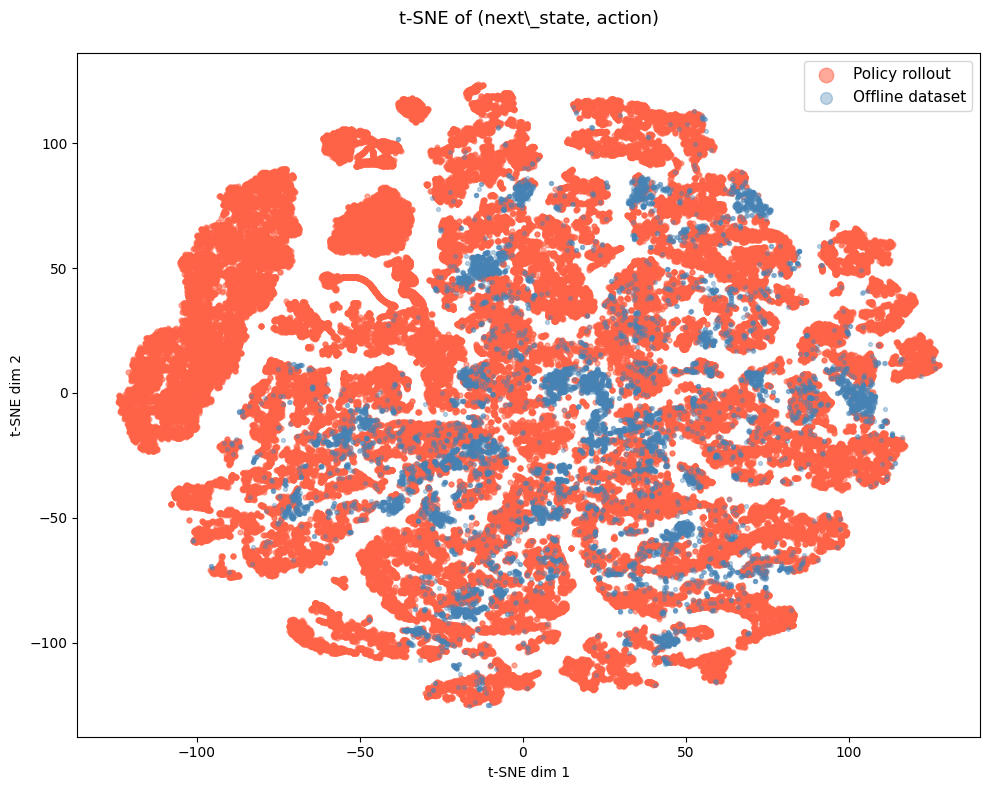

Plot saved to results/tsne_policy_vs_dataset.png


In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(
    emb_rollout[:, 0], emb_rollout[:, 1],
    c='tomato', alpha=0.55, s=12, label='Policy rollout'
)
ax.scatter(
    emb_offline[:, 0], emb_offline[:, 1],
    c='steelblue', alpha=0.35, s=8, label='Offline dataset'
)


task_label    = TASK
sparse_label  = f'sparse {SPARSITY}%' if SPARSITY else 'dense'
density_label = DENSITY_MODEL
# score_label   = f'{d4rl.get_normalized_score(env, np.mean(ep_returns)) * 100:.1f}'

ax.set_title(
    f't-SNE of (next\_state, action)\n',
    fontsize=13,
)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.legend(markerscale=3, fontsize=11)
plt.tight_layout()
plt.savefig('../results/tsne_policy_vs_dataset.png', dpi=150)
plt.show()
print('Plot saved to results/tsne_policy_vs_dataset.png')

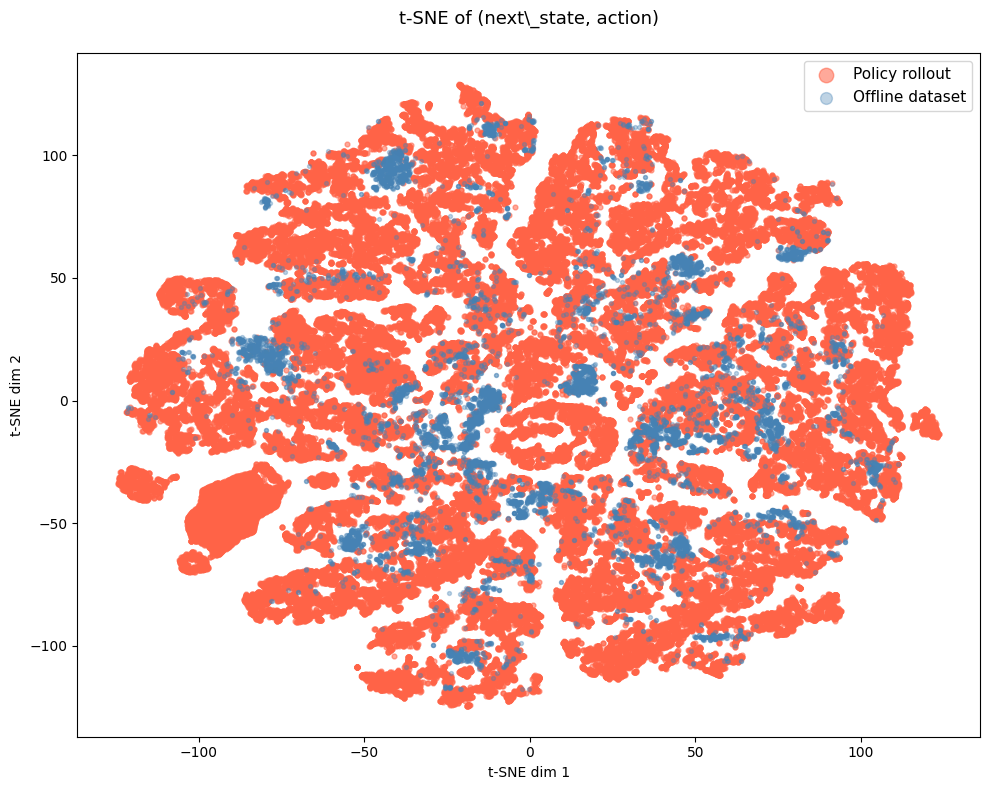

Plot saved to results/tsne_policy_vs_dataset.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(
    emb_rollout[:, 0], emb_rollout[:, 1],
    c='tomato', alpha=0.55, s=12, label='Policy rollout'
)
ax.scatter(
    emb_offline[:, 0], emb_offline[:, 1],
    c='steelblue', alpha=0.35, s=8, label='Offline dataset'
)


task_label    = TASK
sparse_label  = f'sparse {SPARSITY}%' if SPARSITY else 'dense'
density_label = DENSITY_MODEL
# score_label   = f'{d4rl.get_normalized_score(env, np.mean(ep_returns)) * 100:.1f}'

ax.set_title(
    f't-SNE of (next\_state, action)\n',
    fontsize=13,
)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.legend(markerscale=3, fontsize=11)
plt.tight_layout()
plt.savefig('../results/tsne_policy_vs_dataset.png', dpi=150)
plt.show()
print('Plot saved to results/tsne_policy_vs_dataset.png')

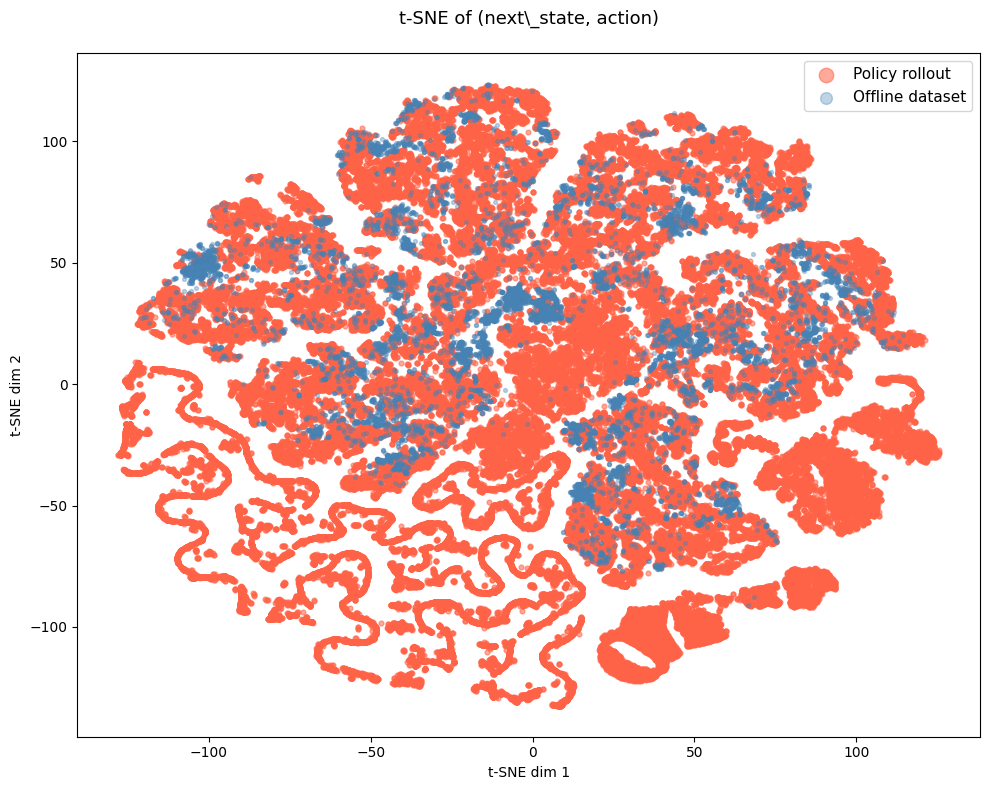

Plot saved to results/tsne_policy_vs_dataset.png


In [26]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(
    emb_rollout[:, 0], emb_rollout[:, 1],
    c='tomato', alpha=0.55, s=12, label='Policy rollout'
)
ax.scatter(
    emb_offline[:, 0], emb_offline[:, 1],
    c='steelblue', alpha=0.35, s=8, label='Offline dataset'
)


task_label    = TASK
sparse_label  = f'sparse {SPARSITY}%' if SPARSITY else 'dense'
density_label = DENSITY_MODEL
# score_label   = f'{d4rl.get_normalized_score(env, np.mean(ep_returns)) * 100:.1f}'

ax.set_title(
    f't-SNE of (next\_state, action)\n',
    fontsize=13,
)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.legend(markerscale=3, fontsize=11)
plt.tight_layout()
plt.savefig('../results/tsne_policy_vs_dataset.png', dpi=150)
plt.show()
print('Plot saved to results/tsne_policy_vs_dataset.png')

## Multi-policy comparison (optional)

Run this section to overlay rollouts from multiple policies / seeds on a single t-SNE.
The offline dataset embedding is shared (computed once above).

In [ ]:
# Define as many policy paths as you like
POLICY_CONFIGS = [
    {
        'label': 'KDE seed 1',
        'density_model': 'kde',
        'path': (
            '/public/gormpo/models/rl/halfcheetah-medium-expert-v2/kde/'
            'seed_1_0112_113039_halfcheetah_medium_expert_v2_gormpo_sparse_72.5/'
            'policy_halfcheetah-medium-expert-v2.pth'
        ),
    },
    # Add more entries here, e.g.:
    # {
    #     'label': 'RealNVP seed 1',
    #     'density_model': 'realnvp',
    #     'path': '/public/gormpo/models/rl/halfcheetah-medium-expert-v2/realnvp/<run>/policy_halfcheetah-medium-expert-v2.pth',
    # },
]

COLORS = ['tomato', 'limegreen', 'darkorange', 'orchid', 'gold']


def multi_policy_tsne(offline_sa, policy_configs, env, obs_dim, action_dim,
                       n_episodes=50, perplexity=40, n_iter=1000, seed=42):
    rng = np.random.default_rng(seed)
    n_off = min(MAX_OFFLINE_SAMPLES, offline_sa.shape[0])
    idx = rng.choice(offline_sa.shape[0], size=n_off, replace=False)
    offline_sub = offline_sa[idx]

    all_blocks  = [offline_sub]
    block_sizes = [len(offline_sub)]
    scores      = []

    for cfg in policy_configs:
        pol = load_policy(cfg['path'], obs_dim, action_dim, env.action_space, DEVICE)
        next_obs_r, actions_r, ep_rets = collect_rollouts(pol, env, n_episodes)
        sa_r = np.concatenate([next_obs_r, actions_r], axis=1)
        all_blocks.append(sa_r)
        block_sizes.append(len(sa_r))
        scores.append(d4rl.get_normalized_score(env, np.mean(ep_rets)) * 100)

    combined = np.concatenate(all_blocks, axis=0)
    scaler_m = StandardScaler()
    combined_scaled = scaler_m.fit_transform(combined)

    print(f'Running t-SNE on {len(combined):,} points...')
    tsne_m = TSNE(n_components=2, perplexity=perplexity, n_iter=n_iter,
                  random_state=seed, verbose=1)
    emb = tsne_m.fit_transform(combined_scaled)

    fig, ax = plt.subplots(figsize=(12, 9))
    start = 0
    # Offline
    end = block_sizes[0]
    ax.scatter(emb[start:end, 0], emb[start:end, 1],
               c='steelblue', alpha=0.3, s=8, label='Offline dataset')
    start = end

    for i, (cfg, sz, sc) in enumerate(zip(policy_configs, block_sizes[1:], scores)):
        end = start + sz
        color = COLORS[i % len(COLORS)]
        label = f"{cfg['label']} ({sc:.1f})"
        ax.scatter(emb[start:end, 0], emb[start:end, 1],
                   c=color, alpha=0.55, s=12, label=label)
        start = end

    ax.set_title('t-SNE of (next_state, action) — multi-policy', fontsize=13)
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    ax.legend(markerscale=3, fontsize=10)
    plt.tight_layout()
    plt.savefig('../results/tsne_multi_policy.png', dpi=150)
    plt.show()
    print('Multi-policy plot saved to results/tsne_multi_policy.png')


offline_sa_full = np.concatenate([offline_next_obs, offline_actions], axis=1)
multi_policy_tsne(
    offline_sa_full, POLICY_CONFIGS, env,
    obs_dim, action_dim,
    n_episodes=N_ROLLOUT_EPISODES,
    perplexity=TSNE_PERPLEXITY,
    n_iter=TSNE_N_ITER,
)

In [ ]:
env.close()